# Read Data

This notebook is used to demonstrate the process of reading in ADCIRC data and updating FEniCSx functions accordingly.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import adcircxtools as at
import adios4dolfinx as adx
import basix.ufl
import dolfinx as dx
import dolfinx.plot
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri
import pyvista as pv
import scipy.interpolate
import scipy.spatial
import ufl

## Read in meshes

In [3]:
# Get main filtered mesh
domain = adx.read_mesh('port_aransas.bp', MPI.COMM_WORLD)

In [4]:
# Get structures for slightly larger mesh
# Used for triangular interpolation
interp_coordinates = np.load('interp_coordinates.npy')
interp_elements = np.load('interp_elements.npy')
interp_node_map = np.load('interp_node_map.npy')
interp_element_map = np.load('interp_element_map.npy')

In [5]:
# Boolean masks for filtering out data points
interp_node_mask = interp_node_map != -1
interp_element_mask = interp_element_map != -1

In [9]:
interp_coordinates

array([[-97.15427277,  27.89931089],
       [-97.15248481,  27.89936386],
       [-97.1533517 ,  27.89736699],
       ...,
       [-97.00935824,  27.73986764],
       [-96.99533508,  27.74802177],
       [-96.9847275 ,  27.75769522]], shape=(6687, 2))

## Apply constant function to mesh

In [7]:
# Read fort.14 for bathymetry
adcirc_mesh = at.mesh.ADCIRCMesh.from_fort_14('../02_mesh/120m_cut.14')

In [11]:
# Get triangulation of bathymetry data
# Use this for interpolation upon a FEniCSx function
# Wrap the interpolator in a function for FEniCSx
triangulation_interp = matplotlib.tri.Triangulation(
    interp_coordinates[:, 0],
    interp_coordinates[:, 1],
    interp_elements
)
bathymetry_interpolator = matplotlib.tri.LinearTriInterpolator(
    triangulation_interp,
    adcirc_mesh.DP[interp_node_mask]
)
def bathy(x):
    return bathymetry_interpolator(x[0], x[1])

In [13]:
# Apply the data to a function
V = dx.fem.functionspace(domain, ('Lagrange', 1))
dp = dx.fem.Function(V)
dp.interpolate(bathy)

/var/folders/nc/8r3mn3bn43b7lyftplq0rtrc0000gn/T/ipykernel_50940/2879582110.py:14: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


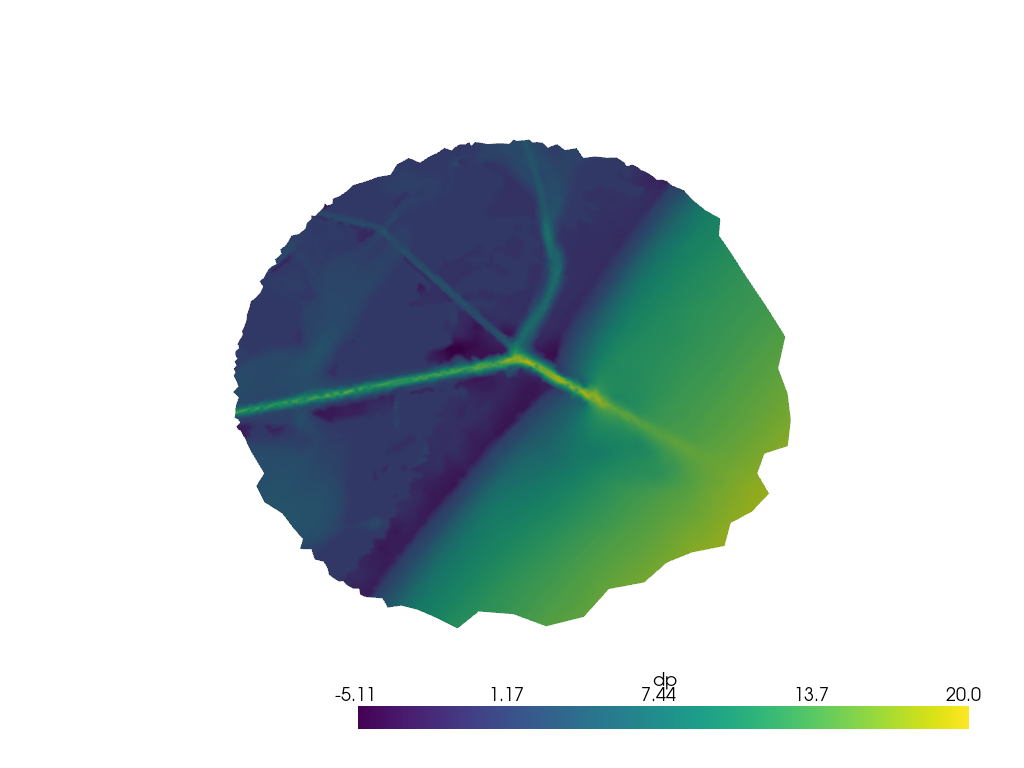

In [14]:
# Visualization to check
topology, cell_types, geometry = dx.plot.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data['dp'] = dp.x.array.real
plotter = pv.Plotter()
plotter.add_mesh(
    grid,
    #scalars='dp',
    #cmap='RdBu',
    #clim=[-1.0, 1.0],
    show_edges=False
)
plotter.view_xy()
plotter.show()

## Apply time-interpolated function to mesh